In [ ]:
!pip install -q giotto-tda

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.6/554.6 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.8/455.8 kB 15.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver el diagrama
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir los valores de la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Incluimos 'crime_lon', 'crime_lat' y la columna de distancias en los datos
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    return diagrams[0]  # Diagrama de persistencia para el primer dataset

# Función para calcular la distancia de Wasserstein entre dos diagramas
def wasserstein_distance_between_diagrams(diag1, diag2):
    # Extraer las coordenadas de nacimiento y muerte
    births1, deaths1 = diag1[:, 0], diag1[:, 1]
    births2, deaths2 = diag2[:, 0], diag2[:, 1]

    # Asegúrate de que ambos diagramas tengan el mismo tamaño
    max_len = max(len(births1), len(births2))
    births1 = np.pad(births1, (0, max_len - len(births1)), constant_values=np.nan)
    deaths1 = np.pad(deaths1, (0, max_len - len(deaths1)), constant_values=np.nan)
    births2 = np.pad(births2, (0, max_len - len(births2)), constant_values=np.nan)
    deaths2 = np.pad(deaths2, (0, max_len - len(deaths2)), constant_values=np.nan)

    # Calcular la distancia de Wasserstein para las coordenadas de nacimiento y muerte
    distance_births = wasserstein_distance(births1[~np.isnan(births1)], births2[~np.isnan(births2)])
    distance_deaths = wasserstein_distance(deaths1[~np.isnan(deaths1)], deaths2[~np.isnan(deaths2)])

    # Combinar las distancias (puedes ajustar este paso si es necesario)
    return distance_births + distance_deaths

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']
#HEAD CHECK
# Archivo CSV
file_path = 'Valencia_Fallas.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias de Wasserstein entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = wasserstein_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias de Wasserstein entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias de Wasserstein entre diagramas de persistencia:
[[0.         0.04543744 0.01925307 0.02024947 0.00787079 0.01491442
  0.00749308 0.0053211  0.0140591  0.04267264 0.01260522]
 [0.04543744 0.         0.0270999  0.02575388 0.05316676 0.06020604
  0.05256067 0.05057825 0.03376973 0.00957629 0.03395348]
 [0.01925307 0.0270999  0.         0.00403336 0.02667675 0.03378742
  0.02604601 0.02418955 0.00958442 0.02394646 0.00840775]
 [0.02024947 0.02575388 0.00403336 0.         0.02752841 0.03456269
  0.0271226  0.02502128 0.01020817 0.0230682  0.00931736]
 [0.00787079 0.05316676 0.02667675 0.02752841 0.         0.00805062
  0.00564979 0.00318981 0.02186313 0.05049912 0.02008221]
 [0.01491442 0.06020604 0.03378742 0.03456269 0.00805062 0.
  0.00802691 0.00995744 0.02889741 0.05753339 0.02711649]
 [0.00749308 0.05256067 0.02604601 0.0271226  0.00564979 0.00802691
  0.         0.00630369 0.02123643 0.0498506  0.01941886]
 [0.0053211  0.05057825 0.02418955 0.02502128 0.00318981 

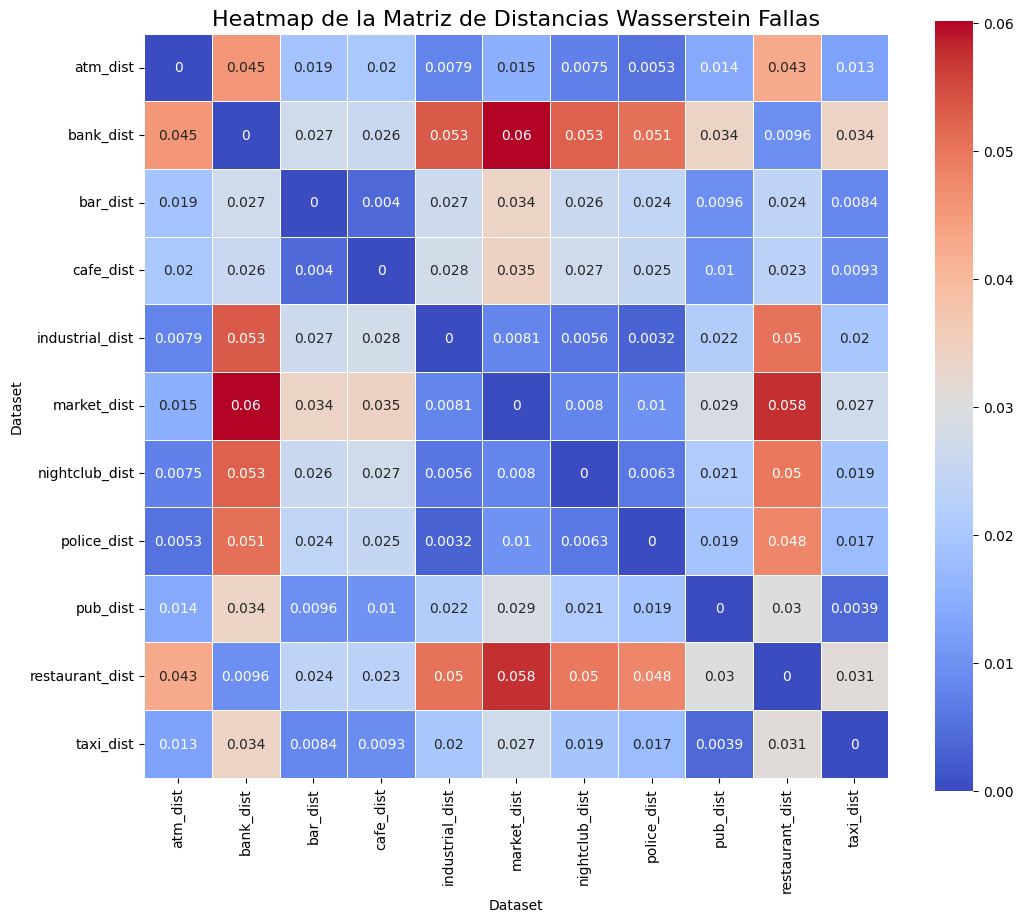

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Wasserstein
dist_matrix_wasserstein = np.array([
    [0.0, 0.04543744, 0.01925307, 0.02024947, 0.00787079, 0.01491442, 0.00749308, 0.0053211, 0.0140591, 0.04267264, 0.01260522],
    [0.04543744, 0.0, 0.0270999, 0.02575388, 0.05316676, 0.06020604, 0.05256067, 0.05057825, 0.03376973, 0.00957629, 0.03395348],
    [0.01925307, 0.0270999, 0.0, 0.00403336, 0.02667675, 0.03378742, 0.02604601, 0.02418955, 0.00958442, 0.02394646, 0.00840775],
    [0.02024947, 0.02575388, 0.00403336, 0.0, 0.02752841, 0.03456269, 0.0271226, 0.02502128, 0.01020817, 0.0230682, 0.00931736],
    [0.00787079, 0.05316676, 0.02667675, 0.02752841, 0.0, 0.00805062, 0.00564979, 0.00318981, 0.02186313, 0.05049912, 0.02008221],
    [0.01491442, 0.06020604, 0.03378742, 0.03456269, 0.00805062, 0.0, 0.00802691, 0.00995744, 0.02889741, 0.05753339, 0.02711649],
    [0.00749308, 0.05256067, 0.02604601, 0.0271226, 0.00564979, 0.00802691, 0.0, 0.00630369, 0.02123643, 0.0498506, 0.01941886],
    [0.0053211, 0.05057825, 0.02418955, 0.02502128, 0.00318981, 0.00995744, 0.00630369, 0.0, 0.0192616, 0.04790039, 0.01748068],
    [0.0140591, 0.03376973, 0.00958442, 0.01020817, 0.02186313, 0.02889741, 0.02123643, 0.0192616, 0.0, 0.02992956, 0.00388009],
    [0.04267264, 0.00957629, 0.02394646, 0.0230682, 0.05049912, 0.05753339, 0.0498506, 0.04790039, 0.02992956, 0.0, 0.03086134],
    [0.01260522, 0.03395348, 0.00840775, 0.00931736, 0.02008221, 0.02711649, 0.01941886, 0.01748068, 0.00388009, 0.03086134, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(dist_matrix_wasserstein, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Wasserstein Fallas', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()


In [ ]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 35.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gudhi import bottleneck_distance
from sklearn.preprocessing import StandardScaler

# Función para cargar datos, calcular el diagrama de persistencia y devolver solo nacimiento y muerte
def calculate_persistence_diagram(file_path, dist_column):
    df = pd.read_csv(file_path)

    # Dividir la columna de distancia por 1000
    df[dist_column] = df[dist_column] / 1000

    # Usar 'crime_lon', 'crime_lat' y la columna de distancia
    data = df[['crime_lon', 'crime_lat', dist_column]].dropna().values  # Eliminar filas con NaN
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    VR = VietorisRipsPersistence()
    diagrams = VR.fit_transform([data_scaled])

    # Filtrar el diagrama para solo incluir las columnas de nacimiento y muerte (dim 0 para H0, dim 1 para H1)
    persistence_diagram = diagrams[0][:, :2]  # Tomar solo las primeras dos columnas: nacimiento y muerte
    return persistence_diagram

# Función para calcular la distancia Bottleneck entre dos diagramas
def bottleneck_distance_between_diagrams(diag1, diag2):
    return bottleneck_distance(diag1, diag2)

# Lista de distancias
dist = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Archivo CSV
file_path = 'Valencia_Fallas.csv'

# Calcular diagramas de persistencia para cada columna de distancias
diagrams = {}
for d in dist:
    diagrams[d] = calculate_persistence_diagram(file_path, d)

# Calcular distancias Bottleneck entre los diagramas usando las distancias
dist_matrix = np.zeros((len(dist), len(dist)))

for i in range(len(dist)):
    for j in range(i + 1, len(dist)):
        dist_val = bottleneck_distance_between_diagrams(diagrams[dist[i]], diagrams[dist[j]])
        dist_matrix[i, j] = dist_val
        dist_matrix[j, i] = dist_val

# Mostrar la matriz de distancias
print("Matriz de distancias Bottleneck entre diagramas de persistencia:")
print(dist_matrix)



Matriz de distancias Bottleneck entre diagramas de persistencia:
[[0.         1.34833312 0.57556033 0.5518508  0.44198227 0.9295392
  0.27676541 0.72204697 0.53812027 1.75790668 0.51999992]
 [1.34833312 0.         1.33351886 1.23545849 1.57094717 1.77646434
  1.40363705 1.76499736 1.32349491 0.99326777 1.40581036]
 [0.57556033 1.33351886 0.         0.68186128 0.71760917 1.26532078
  0.65906173 1.05782855 0.38942516 1.84814632 0.29457009]
 [0.5518508  1.23545849 0.68186128 0.         0.99383307 1.39545918
  0.75197947 1.18796694 0.40197194 1.20605588 0.4227109 ]
 [0.44198227 1.57094717 0.71760917 0.99383307 0.         0.54771161
  0.27781677 0.34021938 0.86210847 1.84814632 0.57112217]
 [0.9295392  1.77646434 1.26532078 1.39545918 0.54771161 0.
  0.75981259 0.26451302 1.40982008 1.85925984 0.99577403]
 [0.27676541 1.40363705 0.65906173 0.75197947 0.27781677 0.75981259
  0.         0.55232036 0.65000749 1.73872948 0.45717418]
 [0.72204697 1.76499736 1.05782855 1.18796694 0.34021938 0.264

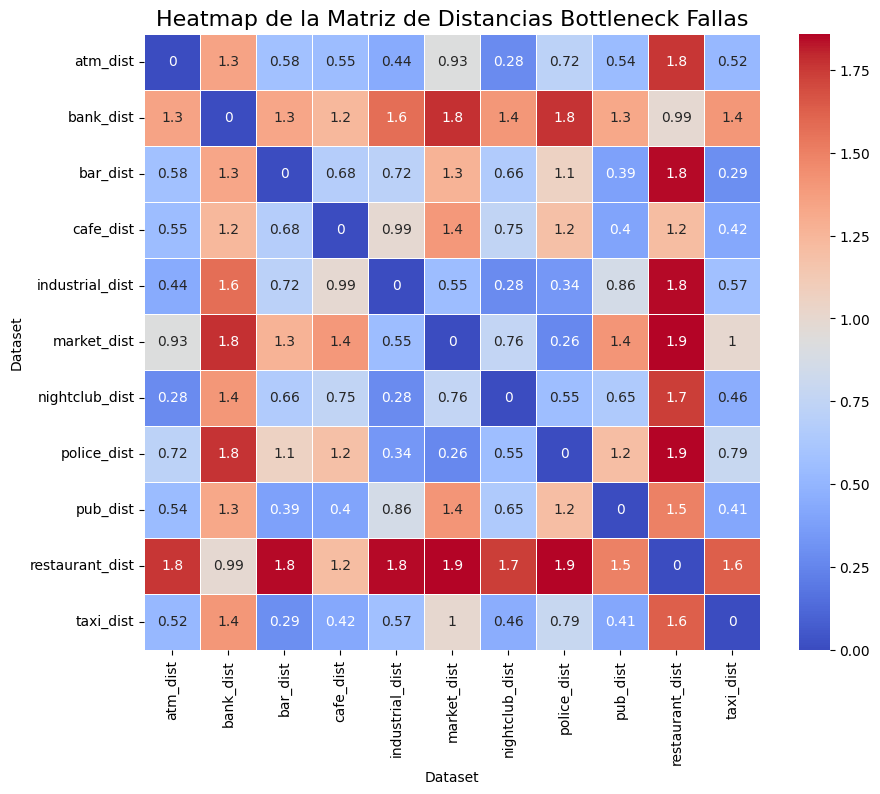

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Nueva matriz de distancias Bottleneck
dist_matrix_bottleneck = np.array([
    [0.0, 1.34833312, 0.57556033, 0.5518508, 0.44198227, 0.9295392, 0.27676541, 0.72204697, 0.53812027, 1.75790668, 0.51999992],
    [1.34833312, 0.0, 1.33351886, 1.23545849, 1.57094717, 1.77646434, 1.40363705, 1.76499736, 1.32349491, 0.99326777, 1.40581036],
    [0.57556033, 1.33351886, 0.0, 0.68186128, 0.71760917, 1.26532078, 0.65906173, 1.05782855, 0.38942516, 1.84814632, 0.29457009],
    [0.5518508, 1.23545849, 0.68186128, 0.0, 0.99383307, 1.39545918, 0.75197947, 1.18796694, 0.40197194, 1.20605588, 0.4227109],
    [0.44198227, 1.57094717, 0.71760917, 0.99383307, 0.0, 0.54771161, 0.27781677, 0.34021938, 0.86210847, 1.84814632, 0.57112217],
    [0.9295392, 1.77646434, 1.26532078, 1.39545918, 0.54771161, 0.0, 0.75981259, 0.26451302, 1.40982008, 1.85925984, 0.99577403],
    [0.27676541, 1.40363705, 0.65906173, 0.75197947, 0.27781677, 0.75981259, 0.0, 0.55232036, 0.65000749, 1.73872948, 0.45717418],
    [0.72204697, 1.76499736, 1.05782855, 1.18796694, 0.34021938, 0.26451302, 0.55232036, 0.0, 1.20232785, 1.85925984, 0.7882818],
    [0.53812027, 1.32349491, 0.38942516, 0.40197194, 0.86210847, 1.40982008, 0.65000749, 1.20232785, 0.0, 1.498492, 0.41404605],
    [1.75790668, 0.99326777, 1.84814632, 1.20605588, 1.84814632, 1.85925984, 1.73872948, 1.85925984, 1.498492, 0.0, 1.62876678],
    [0.51999992, 1.40581036, 0.29457009, 0.4227109, 0.57112217, 0.99577403, 0.45717418, 0.7882818, 0.41404605, 1.62876678, 0.0]
])

# Nombres de los archivos CSV
csv_names = ['atm_dist', 'bank_dist', 'bar_dist', 'cafe_dist', 'industrial_dist',
        'market_dist', 'nightclub_dist', 'police_dist', 'pub_dist',
        'restaurant_dist', 'taxi_dist']

# Crear un heatmap utilizando seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix_bottleneck, annot=True, cmap="coolwarm", cbar=True, square=True, linewidths=.5,
            xticklabels=csv_names, yticklabels=csv_names)

# Añadir etiquetas a los ejes
plt.title('Heatmap de la Matriz de Distancias Bottleneck Fallas', fontsize=16)
plt.xlabel('Dataset')
plt.ylabel('Dataset')

# Mostrar el heatmap
plt.show()
